In [2]:
import sys
import subprocess

try:
    import kagglehub
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "kagglehub"])
    import kagglehub

# Download latest version
path = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ferna\.cache\kagglehub\datasets\ankitverma2010\ecommerce-customer-churn-analysis-and-prediction\versions\1


In [3]:
import pandas as pd
from pathlib import Path
import zipfile

root_path = Path(path)
if root_path.is_file() and root_path.suffix == ".zip":
    extract_dir = root_path.with_suffix("")
    if not extract_dir.exists():
        with zipfile.ZipFile(root_path, "r") as zf:
            zf.extractall(extract_dir)
    root_path = extract_dir

excel_files = list(root_path.rglob("*.xlsx"))
if not excel_files:
    raise FileNotFoundError(f"Aucun fichier Excel trouvé dans {root_path}")

excel_file = excel_files[0]
print("Lecture du fichier Excel :", excel_file)

df = pd.read_excel(excel_file, sheet_name="E Comm")
df.info()

Lecture du fichier Excel : C:\Users\ferna\.cache\kagglehub\datasets\ankitverma2010\ecommerce-customer-churn-analysis-and-prediction\versions\1\E Commerce Dataset.xlsx
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat         

In [4]:
import sys
!{sys.executable} -m pip install shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV


df = pd.read_csv('../data/ecommerce_churn_data.csv')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [6]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


<Axes: >

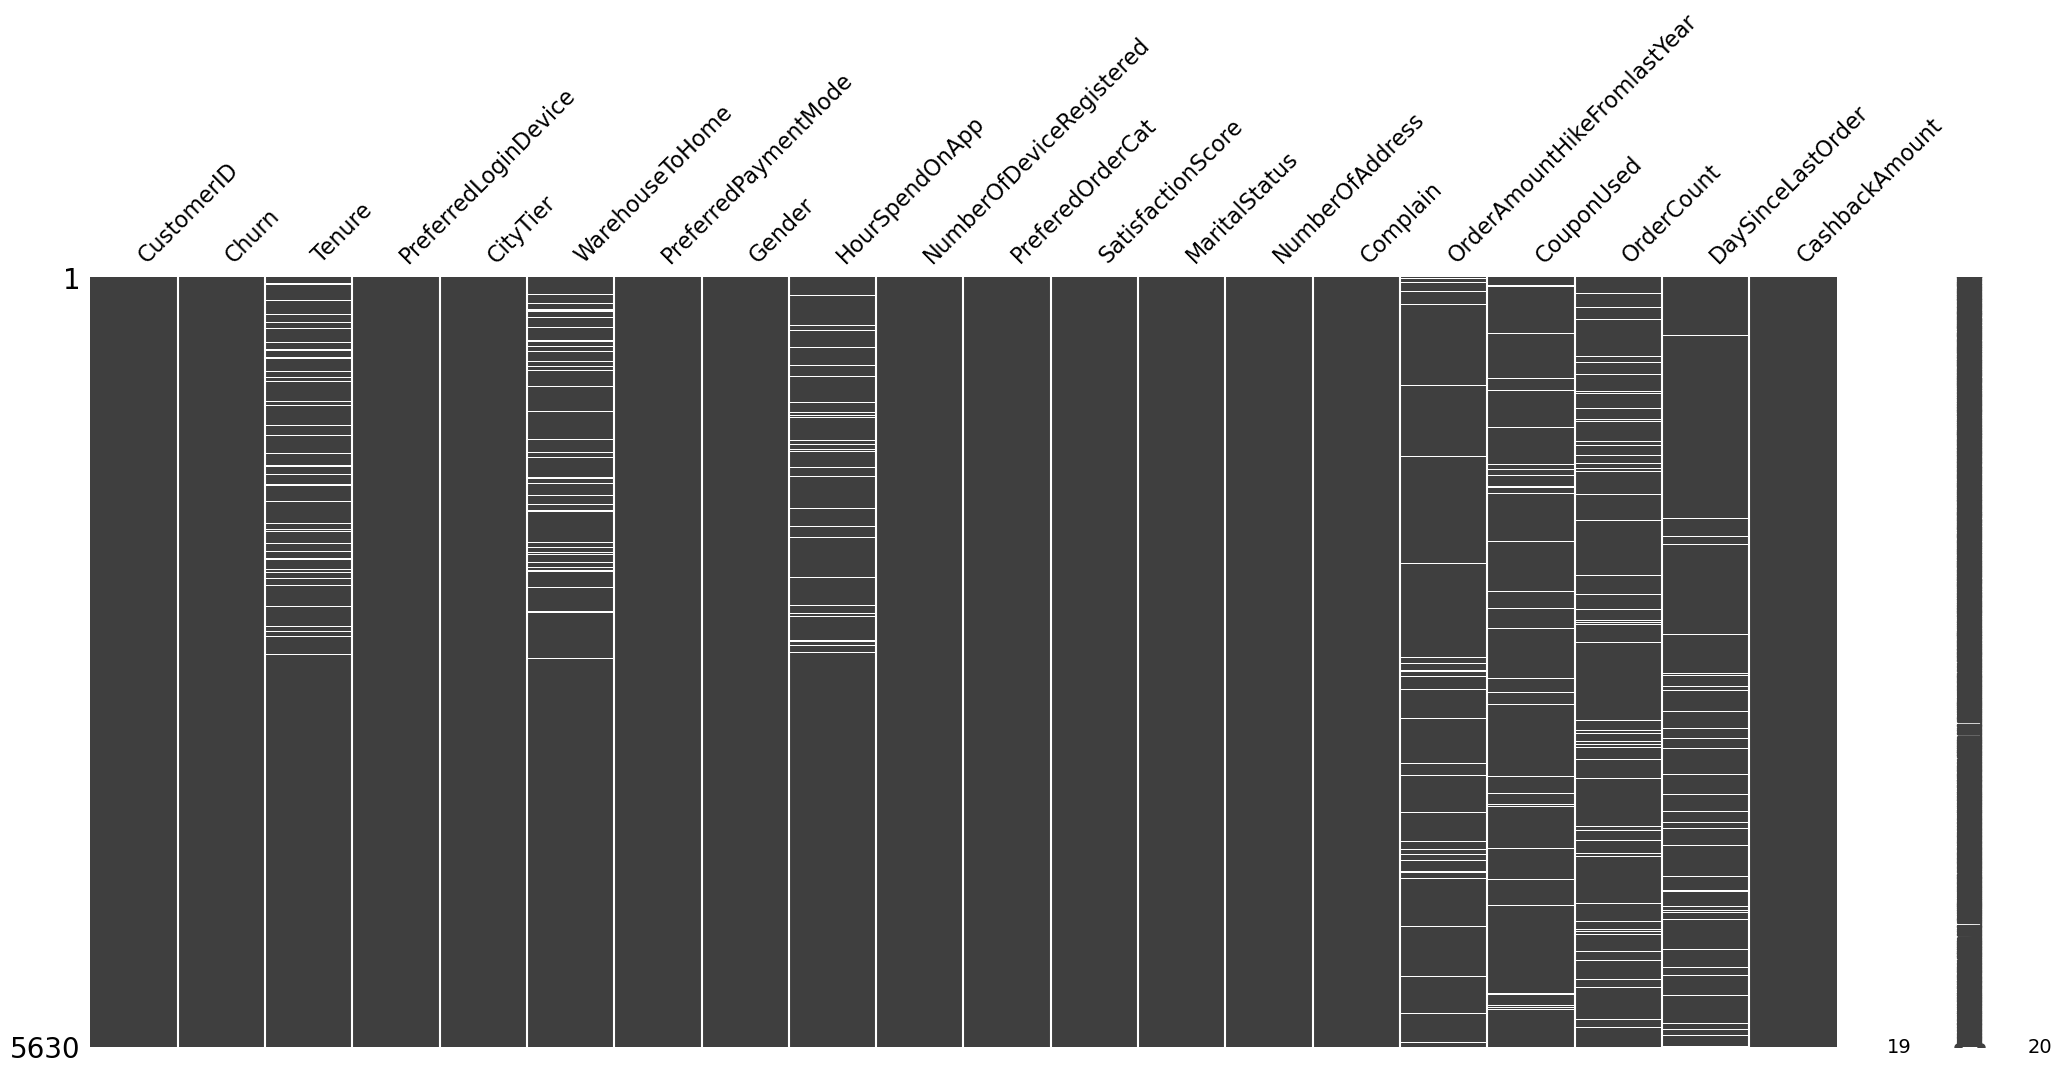

In [7]:
ms.matrix(df)

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing, 
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing'] > 0])

                             Missing  Percentage
Tenure                           264        4.69
WarehouseToHome                  251        4.46
HourSpendOnApp                   255        4.53
OrderAmountHikeFromlastYear      265        4.71
CouponUsed                       256        4.55
OrderCount                       258        4.58
DaySinceLastOrder                307        5.45


In [9]:
df.shape

(5630, 20)

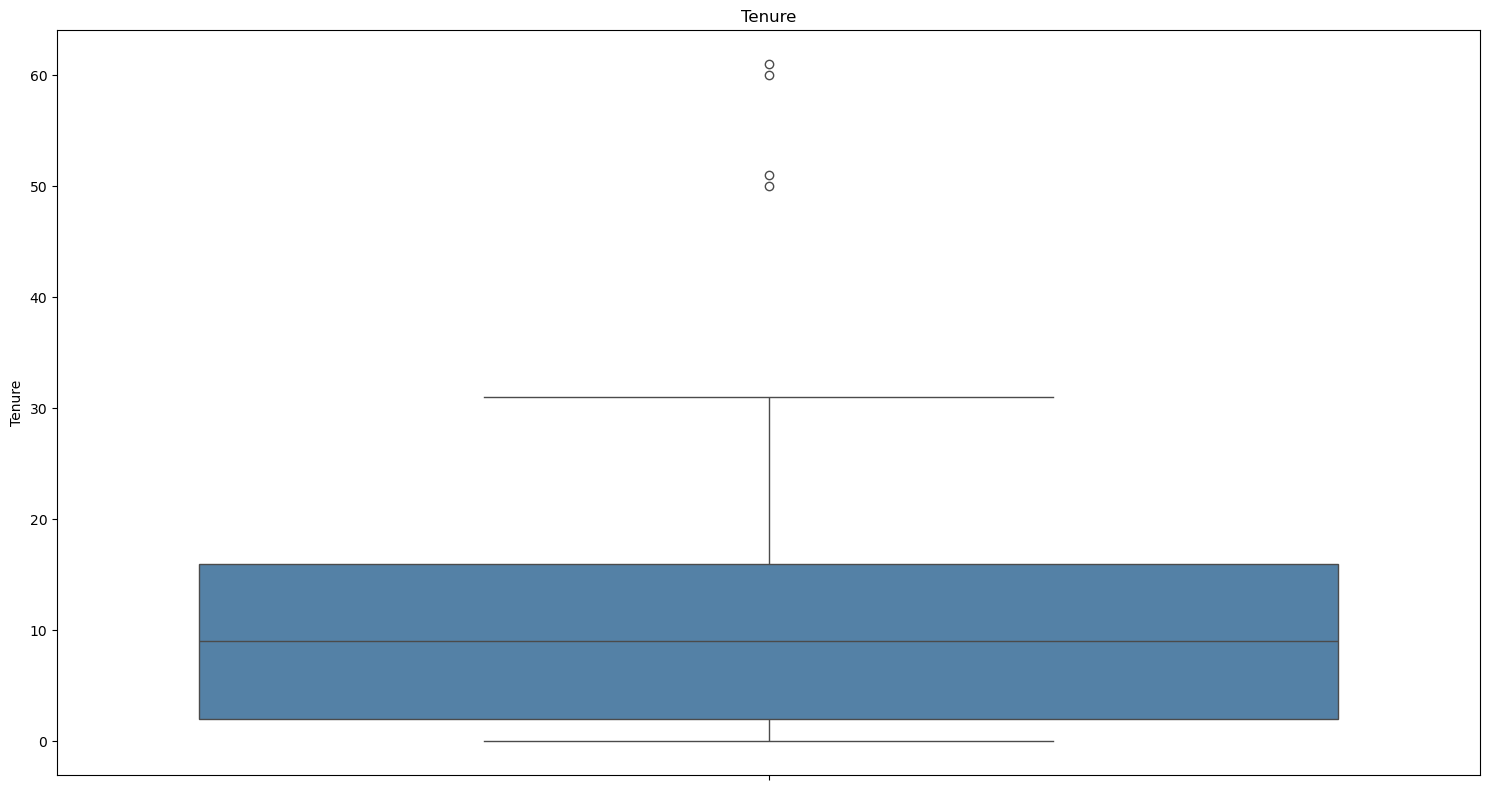

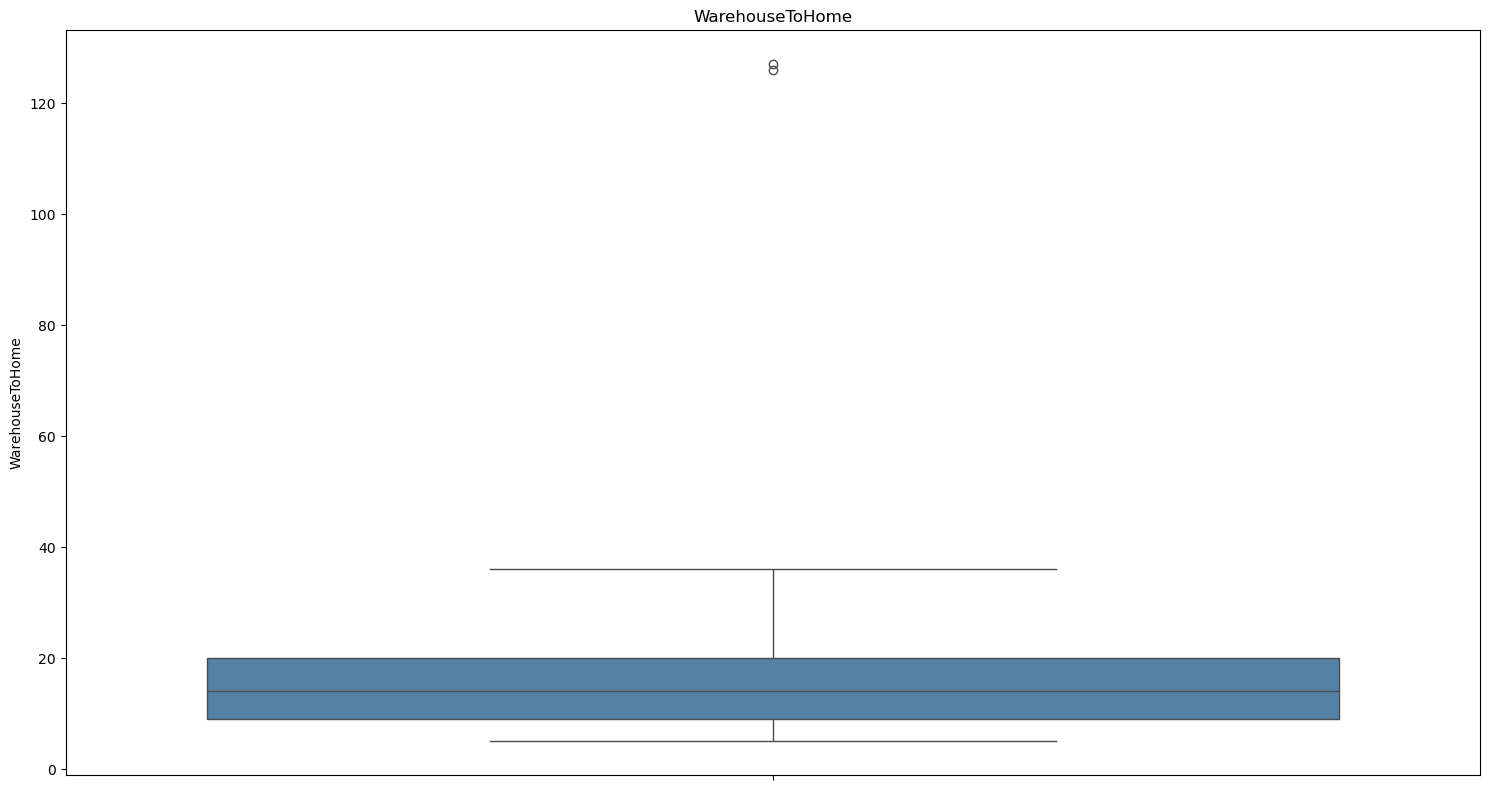

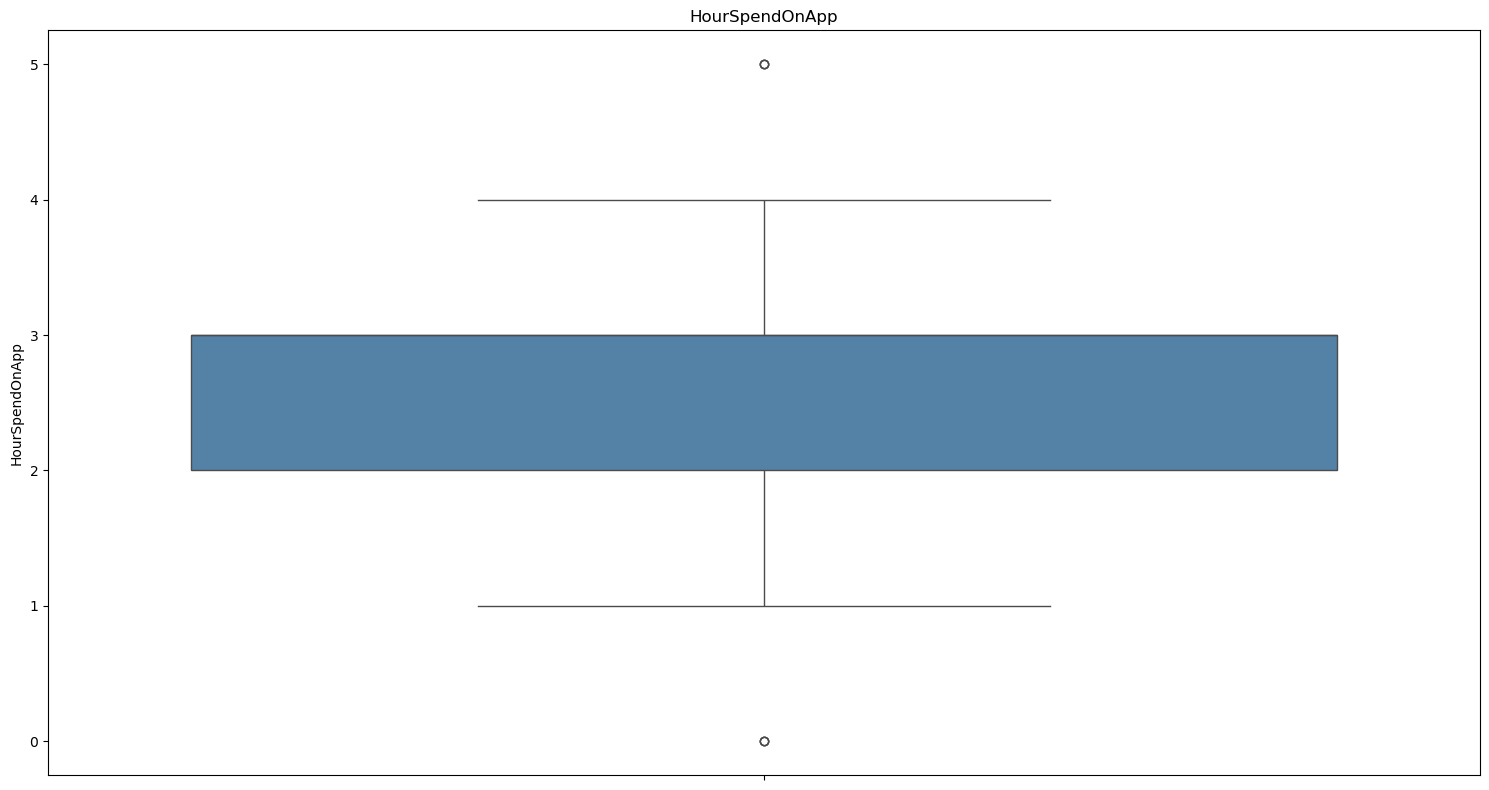

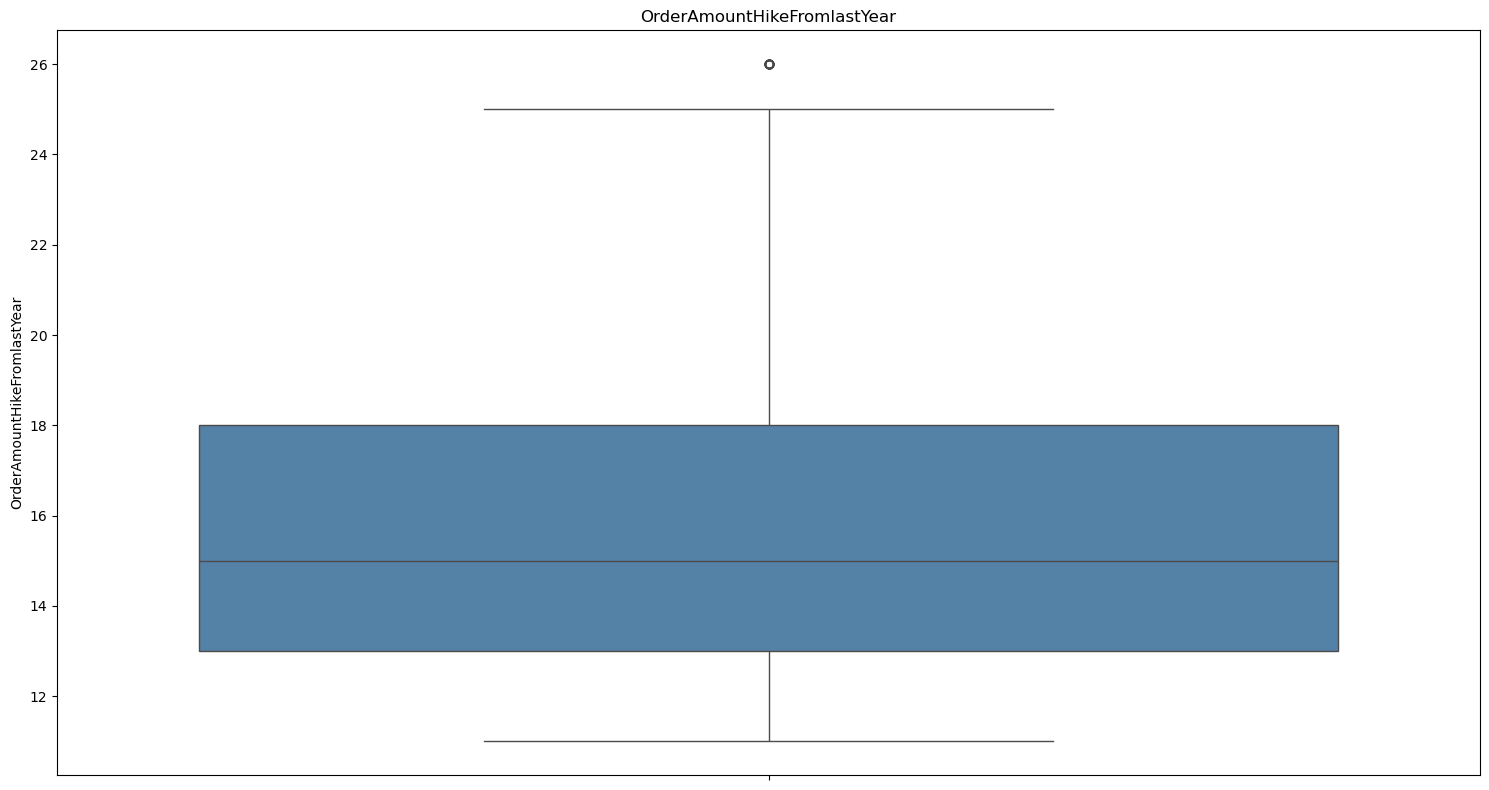

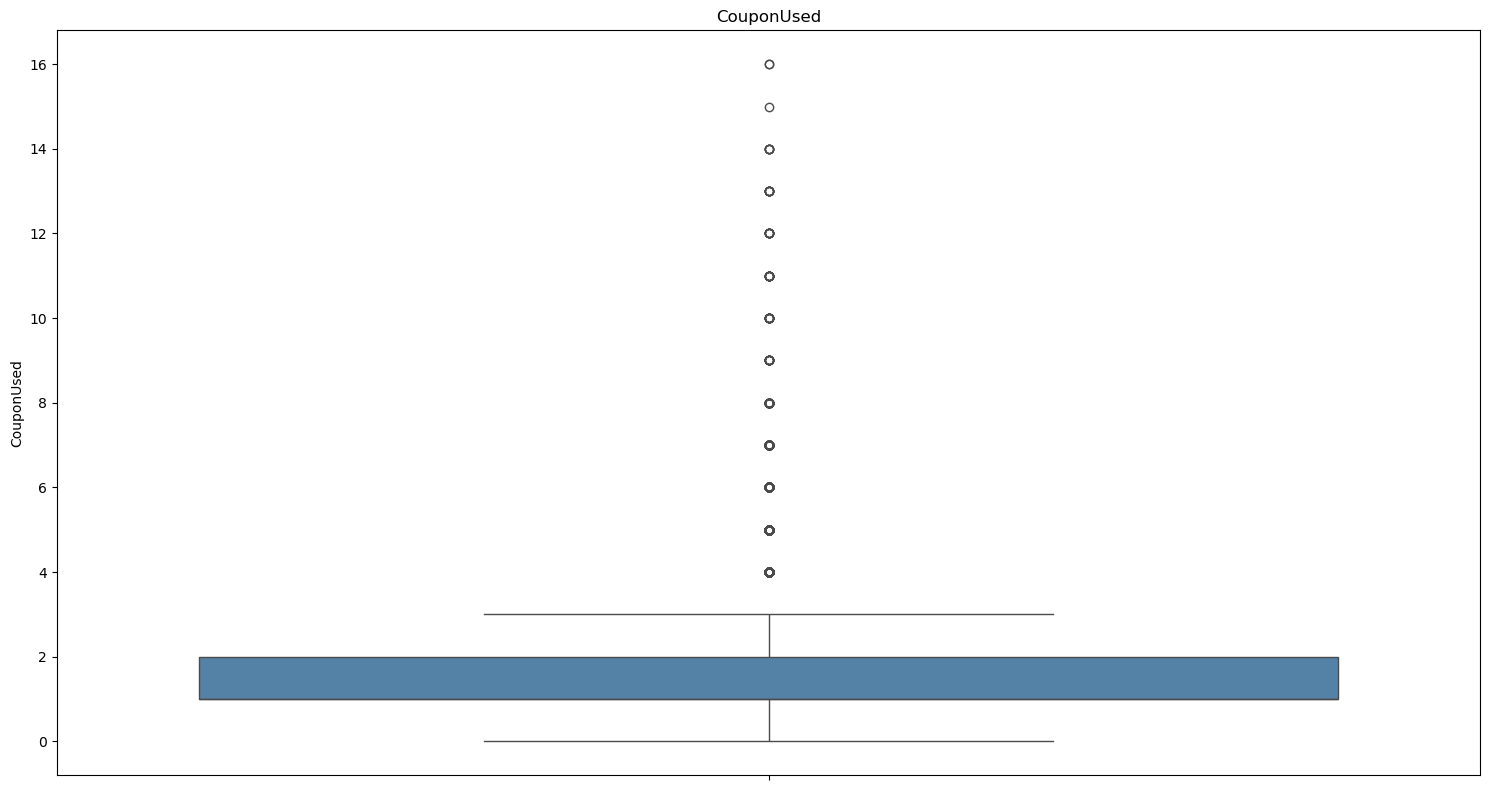

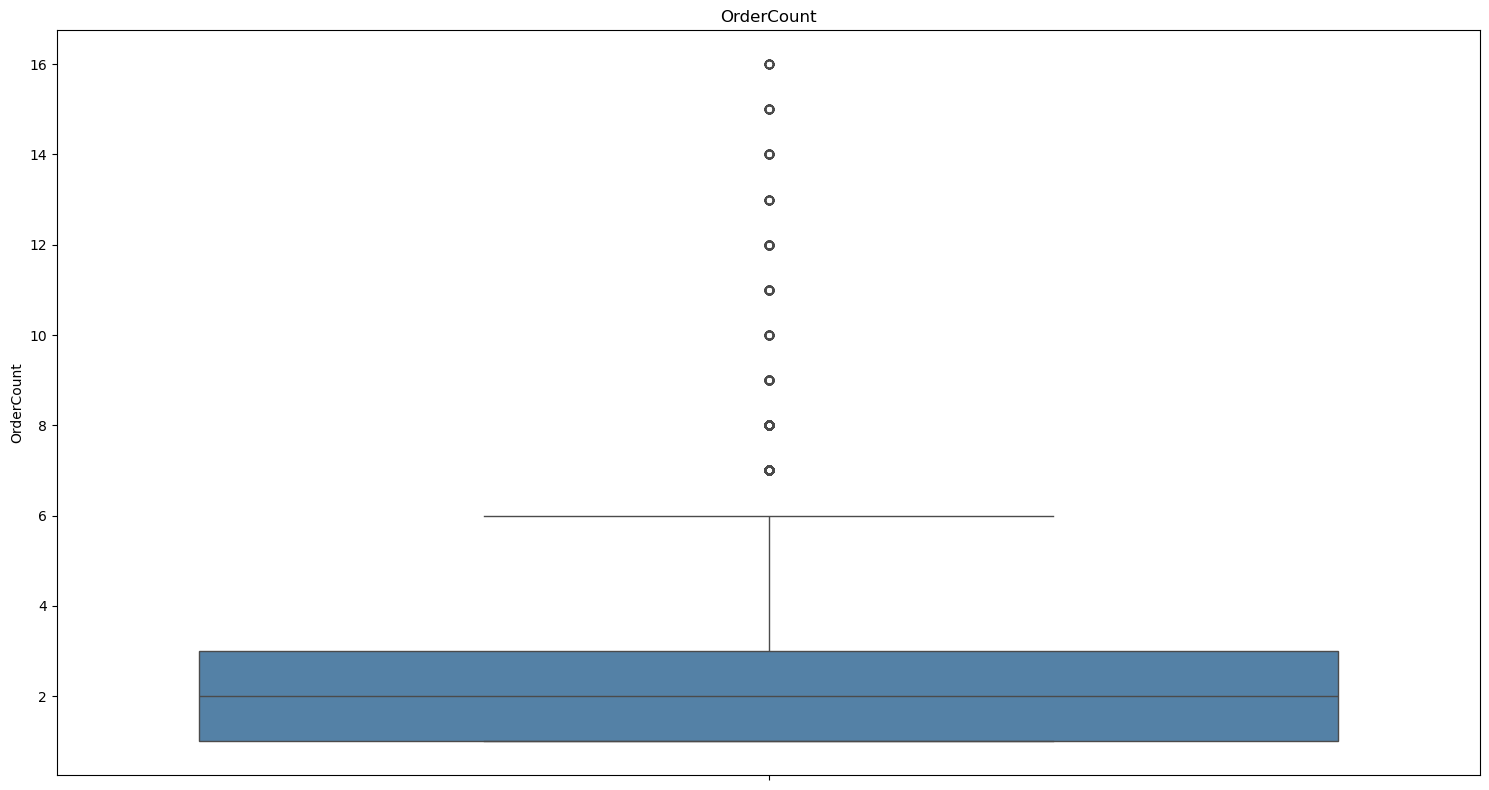

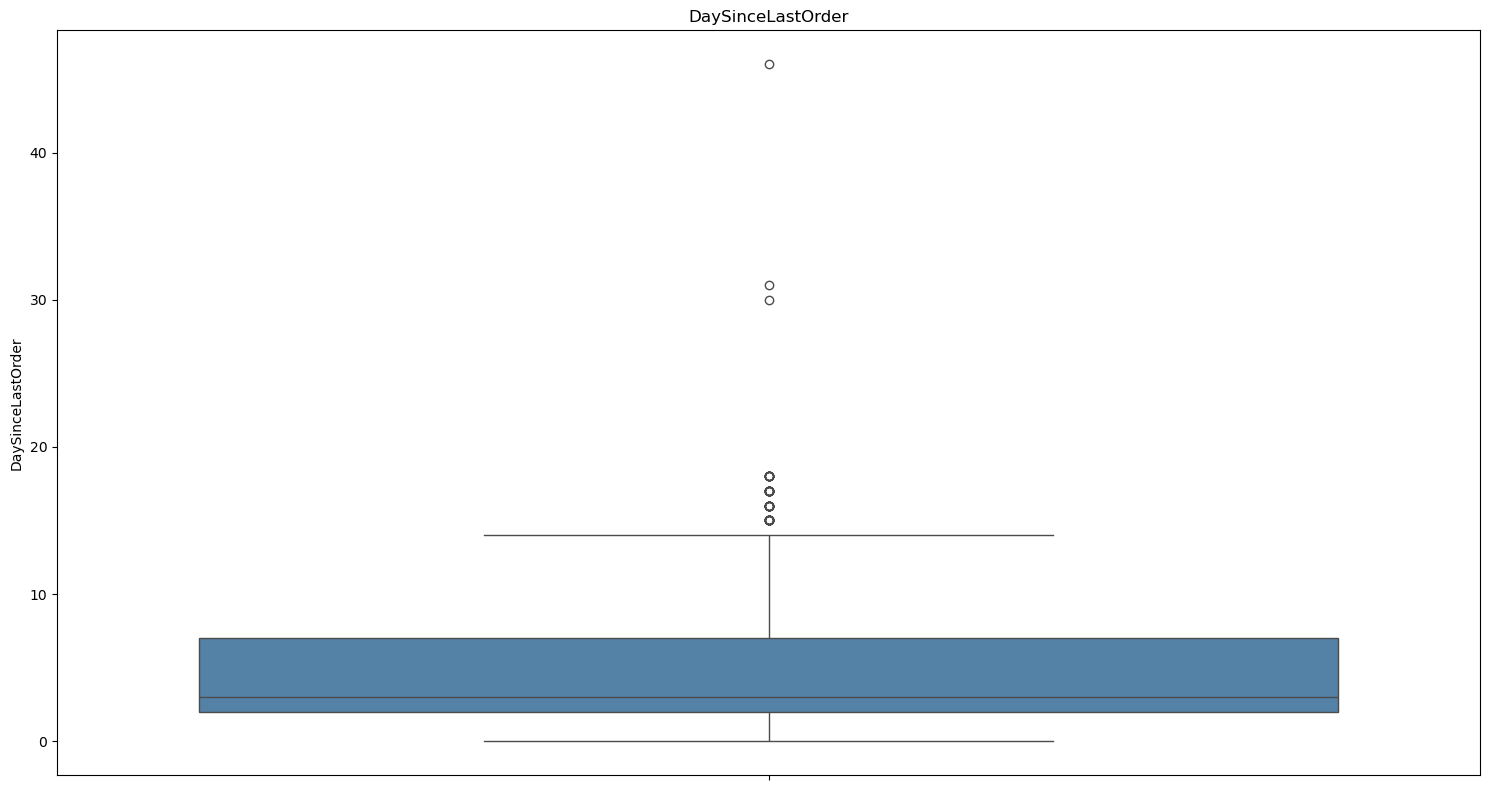

In [10]:
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
            'OrderAmountHikeFromlastYear', 'CouponUsed', 
            'OrderCount', 'DaySinceLastOrder']

for i, col in enumerate(num_cols):
    plt.figure(figsize=(15, 8))
       # plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col], color='steelblue')
    plt.title(col)
    plt.tight_layout()
    plt.show()

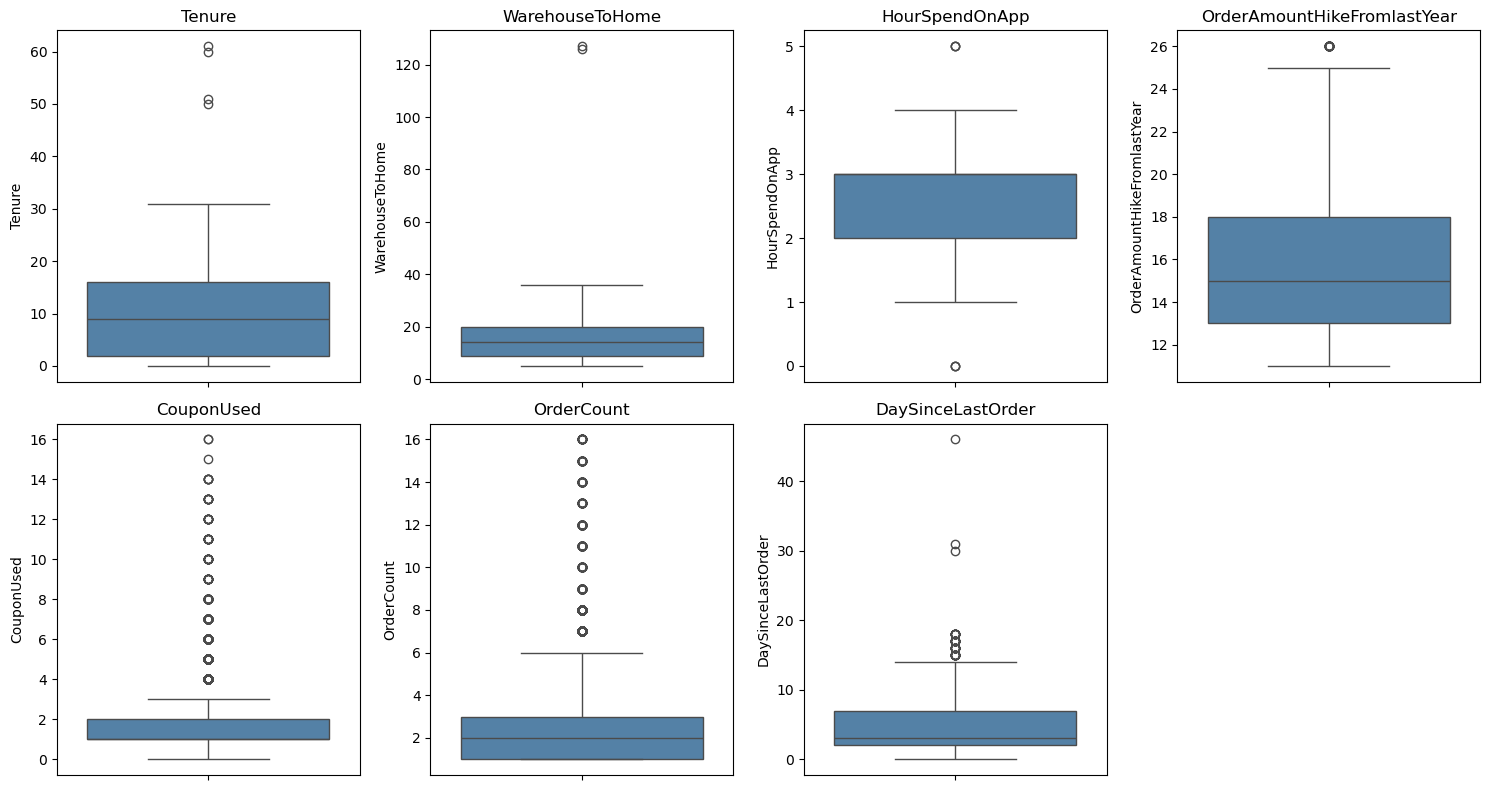

In [11]:
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
            'OrderAmountHikeFromlastYear', 'CouponUsed', 
            'OrderCount', 'DaySinceLastOrder']

plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=df[col], color='steelblue')
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
imputer = KNNImputer(n_neighbors=5)

cols_to_impute = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                  'OrderAmountHikeFromlastYear', 'CouponUsed',
                  'OrderCount', 'DaySinceLastOrder']

df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])

# Vérifie qu'il n'y a plus de valeurs manquantes
print(df[cols_to_impute].isnull().sum())

Tenure                         0
WarehouseToHome                0
HourSpendOnApp                 0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
dtype: int64


In [13]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,10.078224,1.654707,15.641492,2.919609,3.688988,3.066785,4.214032,0.284902,15.703872,1.784405,3.040249,4.583552,177.223030
std,1625.385339,0.374240,8.435760,0.915389,8.392675,0.713075,1.023999,1.380194,2.583586,0.451408,3.619433,1.912554,2.934317,3.619759,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,3.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [14]:
proportions = df['Churn'].value_counts(normalize=True)*100
proportions

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

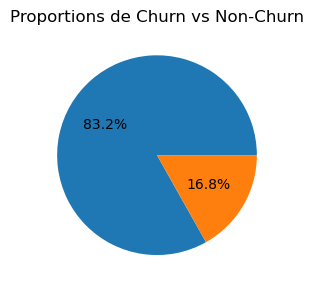

In [15]:
plt.figure(figsize=(6, 3))
plt.pie(proportions, autopct='%1.1f%%')
plt.title('Proportions de Churn vs Non-Churn')
plt.tight_layout()
plt.show()

In [16]:
df.select_dtypes(include='object').columns

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

In [17]:
df_encoded = pd.get_dummies(df, columns=['PreferredLoginDevice', 
                                          'PreferredPaymentMode',
                                          'Gender',
                                          'PreferedOrderCat', 
                                          'MaritalStatus'])

print(df_encoded.shape)
print(df_encoded.columns.tolist())

(5630, 36)
['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'PreferredLoginDevice_Computer', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone', 'PreferredPaymentMode_CC', 'PreferredPaymentMode_COD', 'PreferredPaymentMode_Cash on Delivery', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'Gender_Female', 'Gender_Male', 'PreferedOrderCat_Fashion', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']


In [18]:
non_categorical_cols = df_encoded.select_dtypes(exclude='object').columns.to_list()

In [19]:
non_categorical_cols

['CustomerID',
 'Churn',
 'Tenure',
 'CityTier',
 'WarehouseToHome',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'SatisfactionScore',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount',
 'PreferredLoginDevice_Computer',
 'PreferredLoginDevice_Mobile Phone',
 'PreferredLoginDevice_Phone',
 'PreferredPaymentMode_CC',
 'PreferredPaymentMode_COD',
 'PreferredPaymentMode_Cash on Delivery',
 'PreferredPaymentMode_Credit Card',
 'PreferredPaymentMode_Debit Card',
 'PreferredPaymentMode_E wallet',
 'PreferredPaymentMode_UPI',
 'Gender_Female',
 'Gender_Male',
 'PreferedOrderCat_Fashion',
 'PreferedOrderCat_Grocery',
 'PreferedOrderCat_Laptop & Accessory',
 'PreferedOrderCat_Mobile',
 'PreferedOrderCat_Mobile Phone',
 'PreferedOrderCat_Others',
 'MaritalStatus_Divorced',
 'MaritalStatus_Married',
 'MaritalStatus_Single']

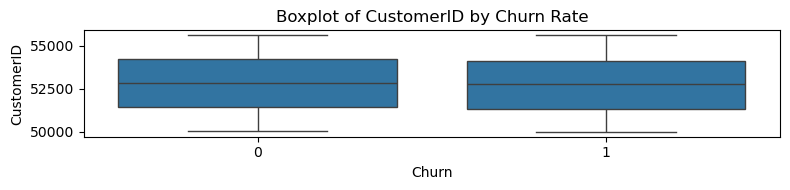

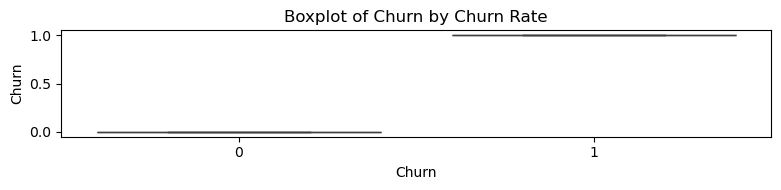

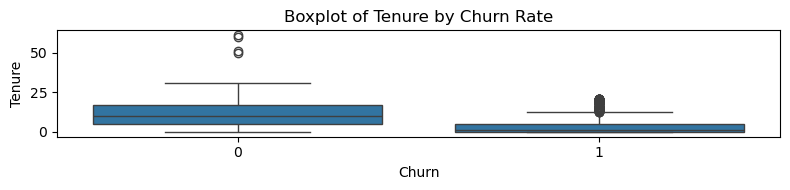

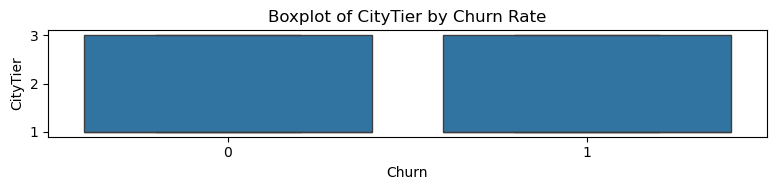

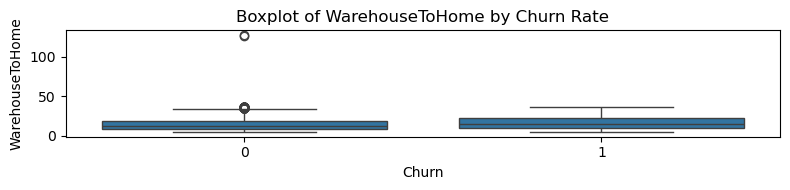

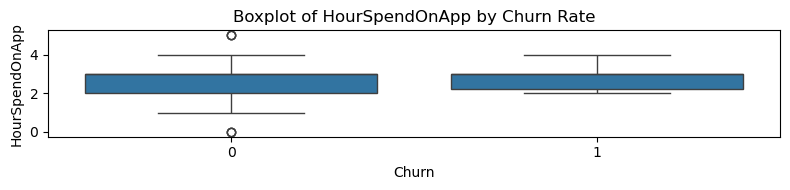

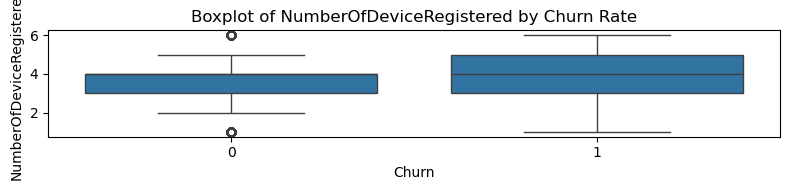

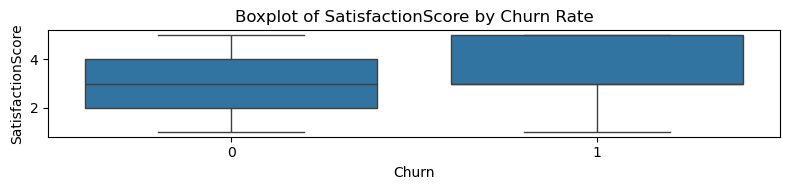

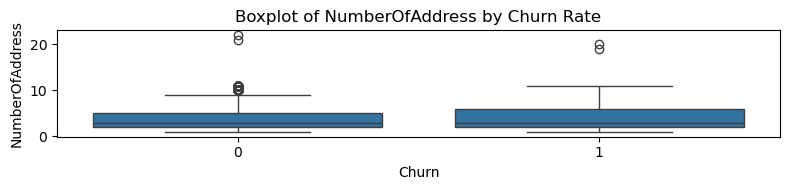

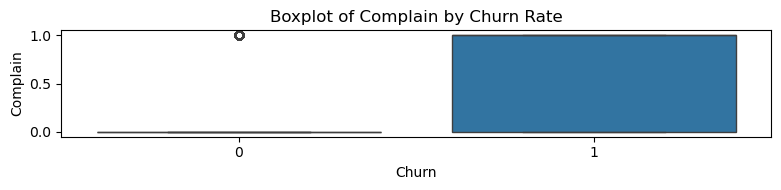

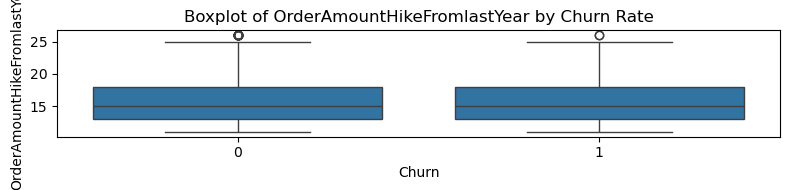

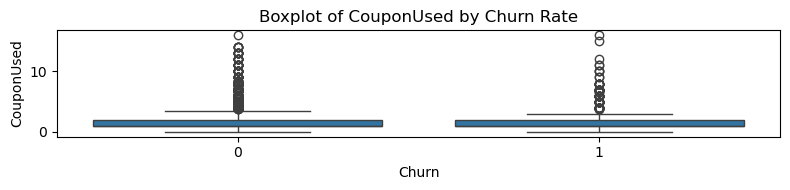

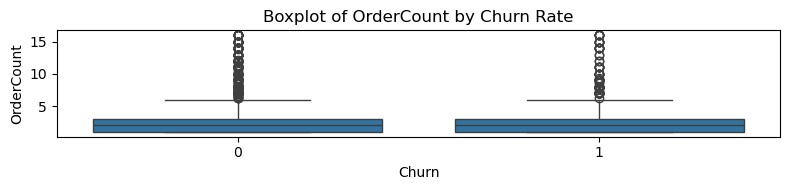

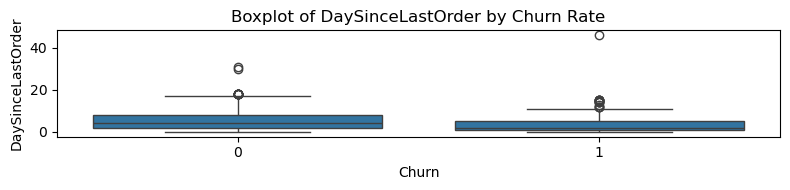

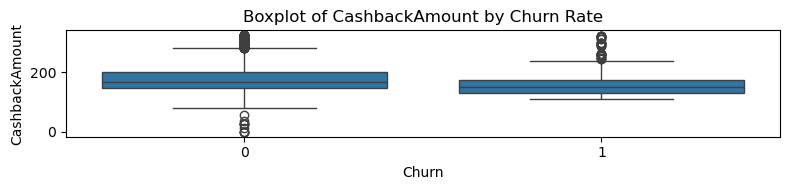

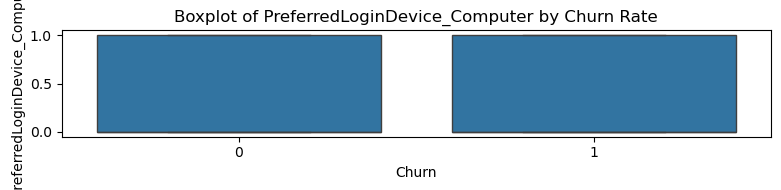

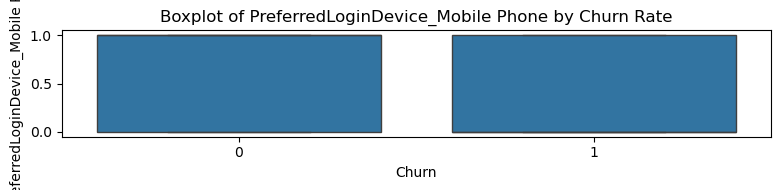

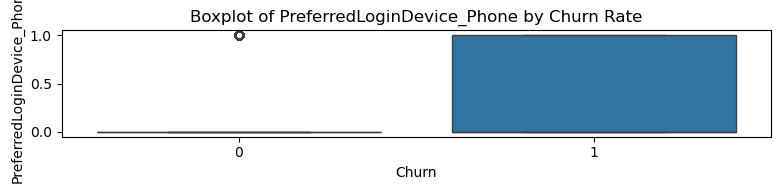

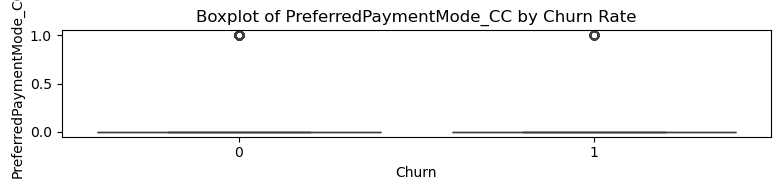

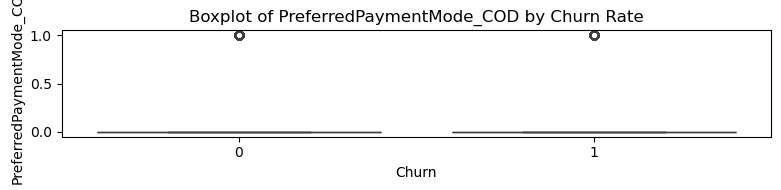

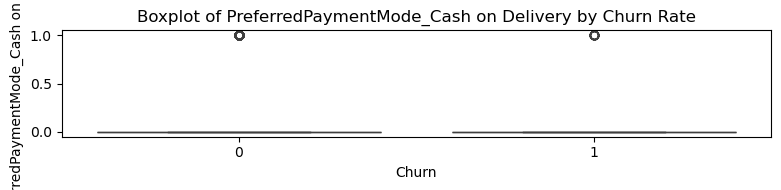

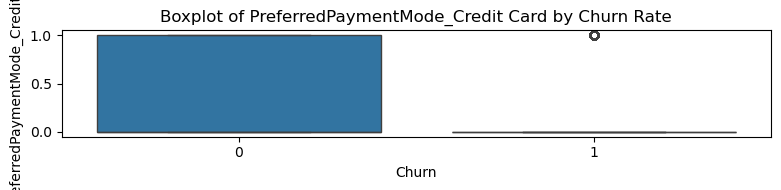

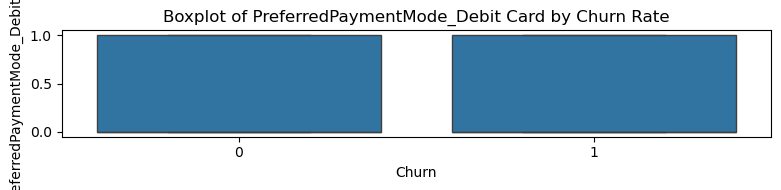

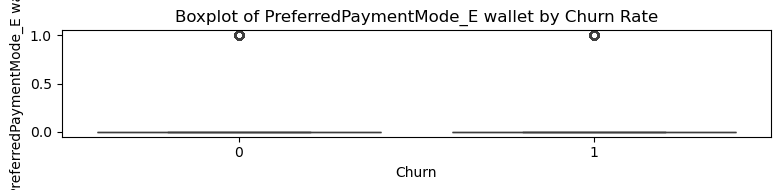

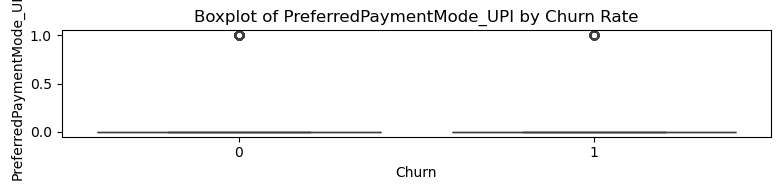

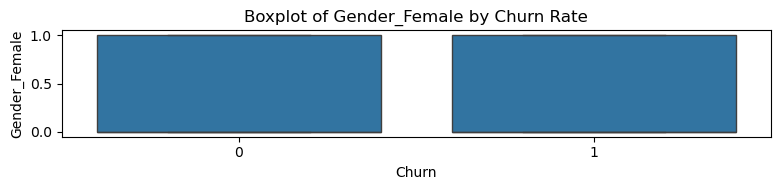

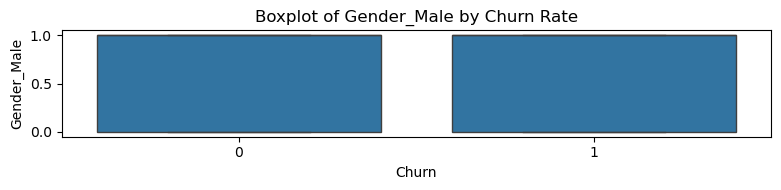

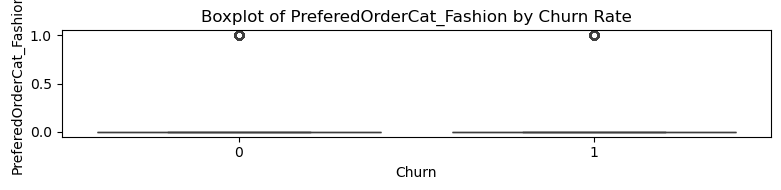

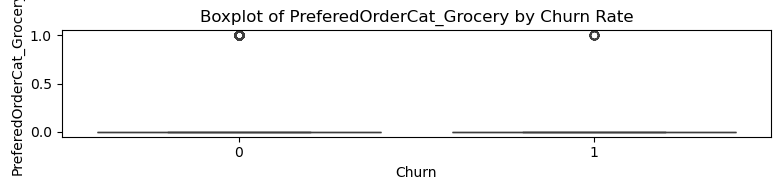

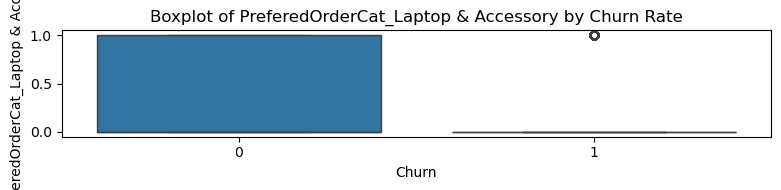

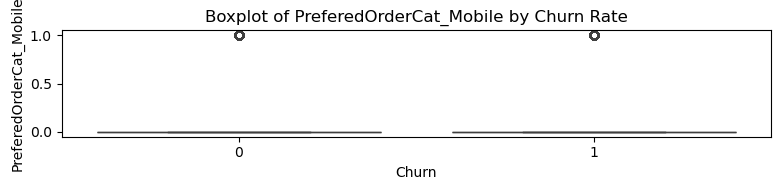

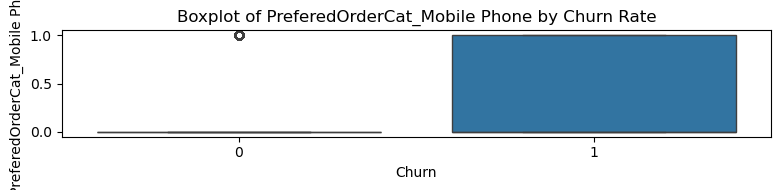

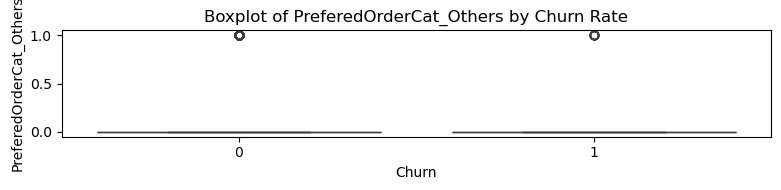

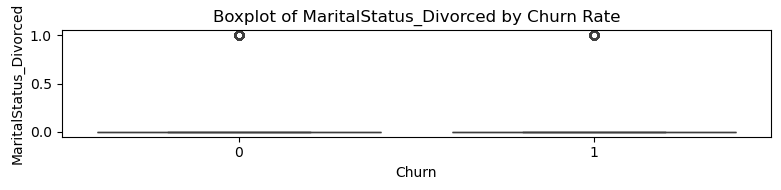

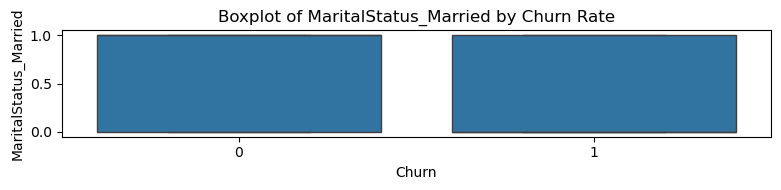

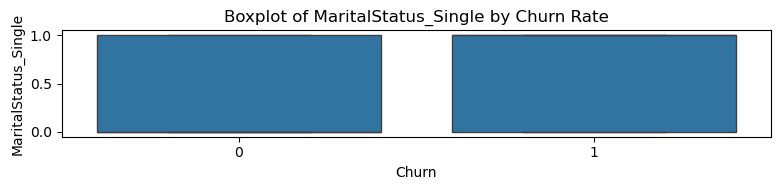

In [20]:
for i, col in enumerate(non_categorical_cols):
    plt.figure(figsize=(8, 2))
    sns.boxplot(data=df_encoded, x='Churn', y=col)
    plt.title(f"Boxplot of {col} by Churn Rate")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

C:\Users\ferna\AppData\Local\Temp\ipykernel_10944\942562793.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Churn'], y=df[col], palette=['steelblue', 'red'])
C:\Users\ferna\AppData\Local\Temp\ipykernel_10944\942562793.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Churn'], y=df[col], palette=['steelblue', 'red'])
C:\Users\ferna\AppData\Local\Temp\ipykernel_10944\942562793.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Churn'], y=df[col], palette=['steelblue', 'red'])
C:\Users\ferna\AppData\Local\Temp\ipykernel

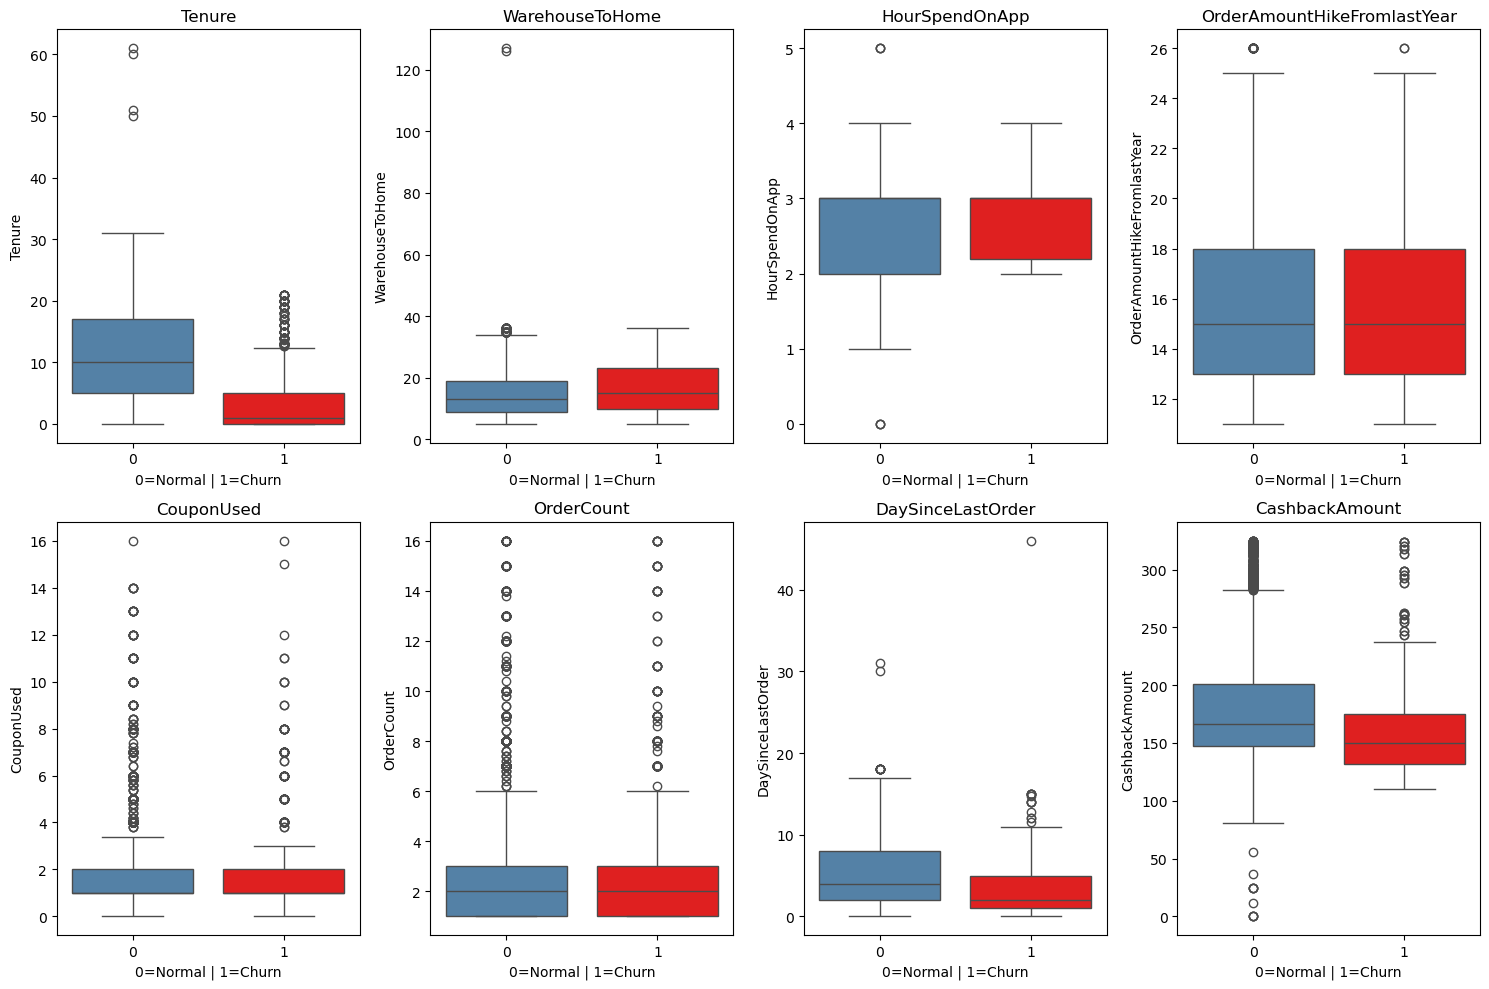

In [21]:
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(x=df['Churn'], y=df[col], palette=['steelblue', 'red'])
    plt.title(col)
    plt.xlabel("0=Normal | 1=Churn")
plt.tight_layout()
plt.show()

In [29]:
import shap

In [30]:
# Variable cible
y = df_encoded['Churn']

# Features — tout sauf la cible
X = df_encoded.drop(columns=['Churn'])

print(f"X: {X.shape} | y: {y.value_counts().to_dict()}")

X: (5630, 35) | y: {0: 4682, 1: 948}


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (4504, 35) | Test: (1126, 35)


In [24]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       936
           1       0.97      0.78      0.87       190

    accuracy                           0.96      1126
   macro avg       0.96      0.89      0.92      1126
weighted avg       0.96      0.96      0.96      1126



In [25]:
scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1')

print(f"F1 par fold: {scores.round(3)}")
print(f"F1 moyen: {scores.mean().round(3)}")
print(f"Écart-type: {scores.std().round(3)}")

F1 par fold: [0.954 0.891 0.93  0.93  0.885]
F1 moyen: 0.918
Écart-type: 0.026


In [26]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres: {grid_search.best_params_}")
print(f"Meilleur F1: {grid_search.best_score_.round(3)}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Meilleurs paramètres: {'model__max_depth': None, 'model__n_estimators': 100}
Meilleur F1: 0.803


In [27]:
y_pred_best = grid_search.best_estimator_.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       936
           1       0.97      0.78      0.87       190

    accuracy                           0.96      1126
   macro avg       0.96      0.89      0.92      1126
weighted avg       0.96      0.96      0.96      1126



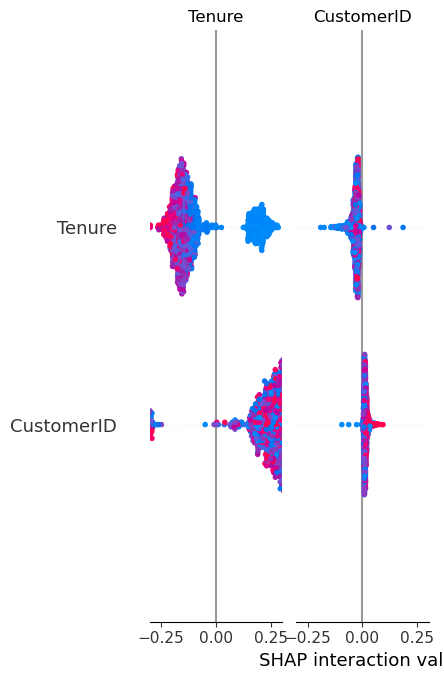

In [31]:
# Extraire le modèle du Pipeline
model_final = grid_search.best_estimator_.named_steps['model']

# Transformer X_test avec le scaler du Pipeline
X_test_scaled = grid_search.best_estimator_.named_steps['scaler'].transform(X_test)

# Calculer les SHAP values
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test_scaled)

# Pour les modèles de classification binaire, shap_values est une liste
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Si shap_values a une colonne en trop (offset), la supprimer
if shap_values.shape[1] == X_test_scaled.shape[1] + 1:
    shap_values = shap_values[:, :-1]

# Créer un DataFrame pour les noms de colonnes
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Visualiser les features les plus importantes
shap.summary_plot(shap_values, X_test_scaled_df)

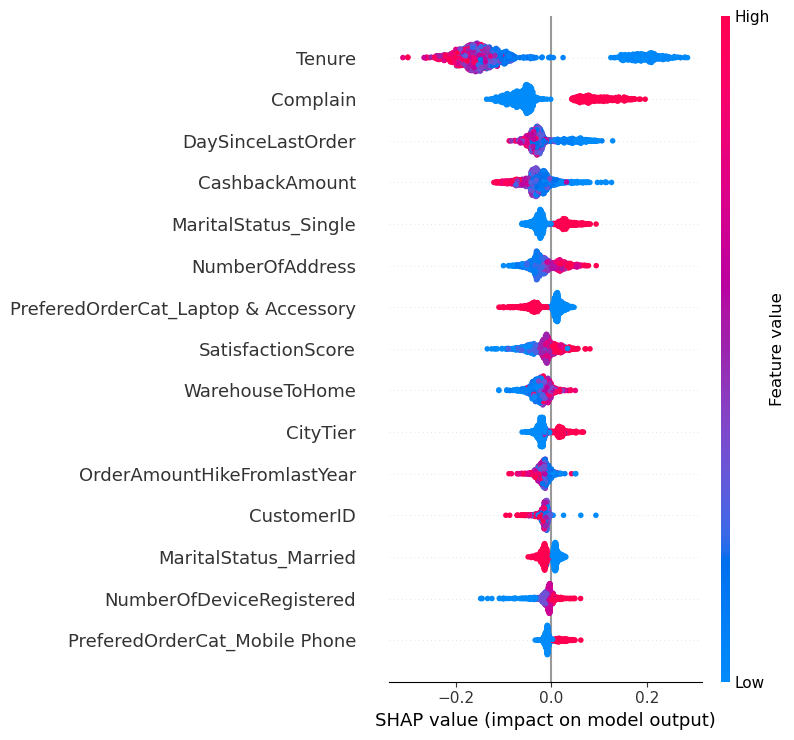

In [32]:
# Extraire le modèle et scaler du Pipeline
model_final = grid_search.best_estimator_.named_steps['model']
scaler = grid_search.best_estimator_.named_steps['scaler']

# Transformer X_test
X_test_scaled = scaler.transform(X_test)

# Convertir en DataFrame pour garder les noms de colonnes
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Calculer SHAP
explainer = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test_scaled_df)

# Visualiser top 15 features
shap.summary_plot(
    shap_values[:, :, 1],  
    X_test_scaled_df,
    max_display=15,
    plot_type="dot"
)